In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset
import h5py

class GalaxyDataset(Dataset):
    """PyTorch Dataset for Galaxy images with metadata from HDF5"""
    def __init__(self, hdf5_path, transform=None):
        self.transform = transform
        with h5py.File(hdf5_path, "r") as f:
            self.images = np.array(f["images"], dtype=np.float32) / 255.0
            self.labels = np.array(f["ans"], dtype=np.int64)
            self.metadata = {key: np.array(f[key]) for key in ["ra", "dec", "redshift", "pxscale"]}

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx]).permute(2, 0, 1)  # HWC -> CHW
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            image = self.transform(image)
        metadata = {key: val[idx] for key, val in self.metadata.items()}
        return image, label, metadata


In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.3):
        super(GalaxyCNN, self).__init__()
        
        # --- Convolutional feature extractor ---
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 256 -> 128
            nn.Dropout(dropout_p),
            
            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 128 -> 64
            nn.Dropout(dropout_p),
            
            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64 -> 32
            nn.Dropout(dropout_p),
            
            # Block 4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),  # Global average pooling
        )
        
        # --- Classifier ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Example usage
# model = GalaxyCNN_Small(num_classes=10).to(device)


In [3]:
from torchvision import transforms

train_transforms = transforms.Compose([
    # # resize in transforms
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomVerticalFlip(),
    # transforms.RandomRotation(180),
])

test_transforms = transforms.Compose([])  # no augmentation


In [4]:
from torch.utils.data import random_split

dataset = GalaxyDataset("../data/Galaxy10_DECals.h5", transform=None)  # transform applied later

test_ratio = 0.25
test_size = int(len(dataset) * test_ratio)
train_size = len(dataset) - test_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Wrap subsets with transforms
from torch.utils.data import Dataset

class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label, meta = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label, meta



In [5]:
train_dataset = TransformedSubset(train_dataset, transform=train_transforms)
test_dataset = TransformedSubset(test_dataset, transform=test_transforms)


In [6]:
import torch
from torch.utils.data import Subset
import random
n = 1000  # replace with whatever number you want

# Make sure n does not exceed the original train dataset size
n = min(n, len(train_dataset))

# Generate random indices
random_indices = random.sample(range(len(train_dataset)), n)

# Create a subset with only these random indices
train_dataset = Subset(train_dataset, random_indices)

In [7]:
from torch.utils.data import DataLoader

batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
)


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



cuda


In [52]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Model ---
model = GalaxyCNN(num_classes=10, dropout_p=0.5).to(device)

# --- Loss and Optimizer ---
criterion = nn.CrossEntropyLoss()  # standard for multi-class classification
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)  # weight decay helps generalization

# --- Optional LR Scheduler ---
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', 
                                                 factor=0.5, patience=3)

# --- Training configuration ---
num_epochs = 30


In [53]:
import matplotlib.pyplot as plt

# Lists to store metrics
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss, correct, total = 0, 0, 0
    for i, (images, labels, meta) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss /= total
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels, _ in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Save metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")



Epoch 1/30 - Train Loss: 2.2766, Train Acc: 0.1310 - Val Loss: 2.2412, Val Acc: 0.0988
Epoch 2/30 - Train Loss: 2.2042, Train Acc: 0.1730 - Val Loss: 2.2814, Val Acc: 0.1464
Epoch 3/30 - Train Loss: 2.1385, Train Acc: 0.2150 - Val Loss: 2.3206, Val Acc: 0.1464
Epoch 4/30 - Train Loss: 2.0871, Train Acc: 0.2290 - Val Loss: 2.0921, Val Acc: 0.2411
Epoch 5/30 - Train Loss: 2.0587, Train Acc: 0.2360 - Val Loss: 2.1153, Val Acc: 0.1865
Epoch 6/30 - Train Loss: 2.0361, Train Acc: 0.2600 - Val Loss: 2.1135, Val Acc: 0.1937
Epoch 7/30 - Train Loss: 2.0291, Train Acc: 0.2490 - Val Loss: 2.0291, Val Acc: 0.2404
Epoch 8/30 - Train Loss: 2.0168, Train Acc: 0.2420 - Val Loss: 2.3079, Val Acc: 0.1534
Epoch 9/30 - Train Loss: 2.0103, Train Acc: 0.2520 - Val Loss: 2.0143, Val Acc: 0.2445
Epoch 10/30 - Train Loss: 1.9901, Train Acc: 0.2520 - Val Loss: 2.1244, Val Acc: 0.2282
Epoch 11/30 - Train Loss: 1.9850, Train Acc: 0.2660 - Val Loss: 1.9901, Val Acc: 0.2546
Epoch 12/30 - Train Loss: 1.9841, Train A

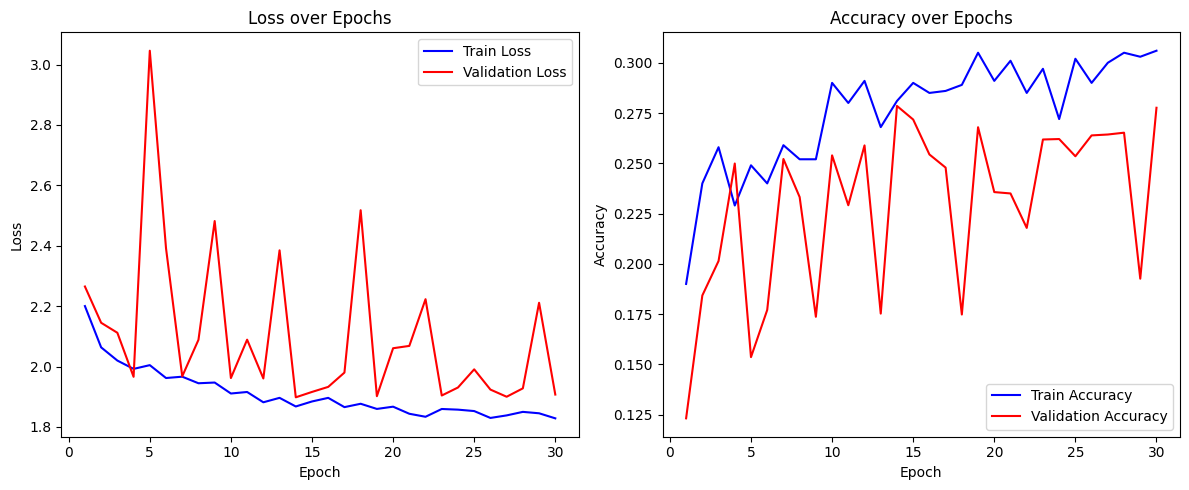

In [44]:
# ---- Visualization ----
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

# Plot Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'b-', label='Train Accuracy')
plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 10
model = GalaxyCNN(num_classes=num_classes, pretrained=False).to(device)

# Replace with your trained weights path
model.eval()

# -------------------------
# 3. Galaxy10 class names
# -------------------------
class_names = [
    "spiral", "elliptical", "lenticular", "irregular", "ring",
    "merger", "dwarf", "s0", "peculiar", "unknown"
]

# -------------------------
# 4. Preprocessing
# -------------------------
preprocess = transforms.Compose([
    # transforms.Resize((256, 256)),
    # transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
    #                      std=[0.229, 0.224, 0.225])
])

# -------------------------
# 5. Prediction function
# -------------------------
def predict_galaxy(image_path, model, class_names):
    image = Image.open(image_path).convert("RGB")
    input_tensor = preprocess(image)
    input_batch = input_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(input_batch)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_idx = torch.argmax(probabilities, dim=1).item()
    
    return {
        "predicted_class": class_names[predicted_idx],
        "predicted_index": predicted_idx,
        "probabilities": probabilities.cpu().numpy()
    }

# Get image from dataset
image, label, metadata = dataset[93]  # already a torch tensor

# Add batch dimension
input_batch = image.unsqueeze(0).to(device)

# Predict
model.eval()
with torch.no_grad():
    outputs = model(input_batch)
    probs = torch.softmax(outputs, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()

print("Predicted class:", class_names[pred_idx])
print("True class:", class_names[label.item()])


d:\ДИПЛОМ_ДІН\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\ДИПЛОМ_ДІН\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Predicted class: s0
True class: spiral


In [32]:
pred_idx

9

In [22]:
idx = 0  # index of the image you want
image, label, metadata = dataset[idx]

print("Image shape:", image.shape)  # should be (3, 256, 256)
print("Label:", label.item())
print("Metadata:", metadata)


Image shape: torch.Size([3, 256, 256])
Label: 0
Metadata: {'ra': np.float64(331.66405522483547), 'dec': np.float64(-0.4841546865670835), 'redshift': np.float64(0.081918865), 'pxscale': np.float64(0.262)}
